# WEEK 9 - Function 2

## Exploitative Bayesian Optimization (Local trust-region GP mean) + Progress Validation

### What changed this week
- Switched to `bayesian_optimization_exploitative_2.py`.
- Aggregate duplicate and near-duplicate inputs before fitting the GP.
- Added a GP noise term (`WhiteKernel`) so repeated evaluations do not create unrealistic spikes.
- Replaced global mean maximization with local trust-region exploitation around the incumbent.
- Removed output clipping; the proposed row now uses the raw GP predicted mean.

### What we're doing this week
- Re-running **Function 2** with **exploitative BO**: fit GP, suggest the next point by **maximizing GP mean locally** near the incumbent (no EI).
- Same validation workflow and reporting structure; next-point recommendation saved to `results/function2_next_point.json`.

### Why mean-only (exploitative)
- **Output value** for the proposed row is the **GP predicted mean** only.
- The new BO stays near the incumbent instead of chasing unstable global spikes.


### STEP 0 - IMPORT RELEVANT PACKAGES

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

import sys
sys.path.append('../..')  # Go up two levels to project root

import importlib
import scripts.utils.data_utils as data_utils
importlib.reload(data_utils)

# Import utility functions
from scripts.utils.data_utils import (
    load_initial_data,
    load_week1_data,
    load_week2_data,
    load_week3_data,
    load_week4_data,
    _load_latest_week_data,
    plot_2d_scatter_with_distribution,
    plot_3d_scatter_with_distribution,
    plot_tsne_with_distribution,
)

# Week 9 changes: use local exploitative BO with duplicate aggregation and a noise-aware GP
import scripts.bayesian_optimisation.bayesian_optimization_exploitative_2 as bo_module
importlib.reload(bo_module)
from scripts.bayesian_optimisation.bayesian_optimization_exploitative_2 import SimpleBayesianOptimization



### STEP 1 - LOAD INITIAL DATA

In [21]:
# Load initial data using utility function
base_dir = Path('../../data/initial_data')
initial_data = load_initial_data(base_dir)

print(f"Loaded initial data for {len(initial_data)} functions")
for function_name, data in initial_data.items():
    print(f"  {function_name}: {data['inputs'].shape[0]} samples, {data['inputs'].shape[1]} dimensions")

Loaded initial data for 8 functions
  function_1: 10 samples, 2 dimensions
  function_2: 10 samples, 2 dimensions
  function_3: 15 samples, 3 dimensions
  function_4: 30 samples, 4 dimensions
  function_5: 20 samples, 4 dimensions
  function_6: 20 samples, 5 dimensions
  function_7: 30 samples, 6 dimensions
  function_8: 40 samples, 8 dimensions


### STEP 2 - LOAD WEEK 1 DATA

In [22]:
# Load week1 data using utility function
week1_dir = Path('../../data/week1')
week1_data = load_week1_data(week1_dir)

print(f"Loaded week1 data for {len(week1_data)} functions")
for function_name, data in week1_data.items():
    print(f"  {function_name}: Input shape = {data['input'].shape}, Output = {data['output']}")

Loaded week1 data for 8 functions
  function_1: Input shape = (2,), Output = 2.6752879910742468e-09
  function_2: Input shape = (2,), Output = 0.42721035515778233
  function_3: Input shape = (3,), Output = -0.45300818056360315
  function_4: Input shape = (4,), Output = -25.81769735182645
  function_5: Input shape = (4,), Output = 4219.157963029058
  function_6: Input shape = (5,), Output = -2.6736180536592746
  function_7: Input shape = (6,), Output = 0.013680510023283559
  function_8: Input shape = (8,), Output = 6.0739207860211


### STEP 3 - LOAD WEEK 2 DATA

In [23]:
# Load week2 data using utility function
week2_dir = Path('../../data/week2')
week2_data = load_week2_data(week2_dir)

print(f"Loaded week2 data for {len(week2_data)} functions")
for function_name, data in week2_data.items():
    print(f"  {function_name}: Input shape = {data['input'].shape}, Output = {data['output']}")

Loaded week2 data for 8 functions
  function_1: Input shape = (2,), Output = 2.308810742126141e-248
  function_2: Input shape = (2,), Output = 0.09143573616583116
  function_3: Input shape = (3,), Output = -0.16648410423830667
  function_4: Input shape = (4,), Output = 0.07635232865804342
  function_5: Input shape = (4,), Output = 4139.609565498906
  function_6: Input shape = (5,), Output = -1.732308297257106
  function_7: Input shape = (6,), Output = 1.9964705720993239
  function_8: Input shape = (8,), Output = 9.8362097005135


### STEP 4 - LOAD WEEK 3 DATA

In [24]:
# Load week3 data using utility function
week3_dir = Path('../../data/week3')
week3_data = load_week3_data(week3_dir)

print(f"Loaded week3 data for {len(week3_data)} functions")
for function_name, data in week3_data.items():
    print(f"  {function_name}: Input shape = {data['input'].shape}, Output = {data['output']}")

Loaded week3 data for 8 functions
  function_1: Input shape = (2,), Output = 0.025559285339829783
  function_2: Input shape = (2,), Output = 0.3317119096486708
  function_3: Input shape = (3,), Output = -0.16364425027712573
  function_4: Input shape = (4,), Output = -2.443739075344467
  function_5: Input shape = (4,), Output = 4205.41112909808
  function_6: Input shape = (5,), Output = -1.2341261163607111
  function_7: Input shape = (6,), Output = 0.8888266866145418
  function_8: Input shape = (8,), Output = 9.9008337717904


### STEP 5 - LOAD WEEK 4 DATA

In [25]:
# Load week4 data using utility function
week4_dir = Path('../../data/week4')
week4_data = load_week4_data(week4_dir)

print(f"Loaded week4 data for {len(week4_data)} functions")
for function_name, data in week4_data.items():
    print(f"  {function_name}: Input shape = {data['input'].shape}, Output = {data['output']}")

Loaded week4 data for 8 functions
  function_1: Input shape = (2,), Output = -1.147039773167018e-58
  function_2: Input shape = (2,), Output = 0.3737737205169543
  function_3: Input shape = (3,), Output = -0.15055016501019017
  function_4: Input shape = (4,), Output = -0.05937246575917099
  function_5: Input shape = (4,), Output = 1072.3460141230023
  function_6: Input shape = (5,), Output = -2.002317401777197
  function_7: Input shape = (6,), Output = 2.7733922523082737
  function_8: Input shape = (8,), Output = 9.821645117996


### STEP 6 - LOAD WEEK 5 DATA

In [26]:
# Load week5 data using utility function
week5_dir = Path('../../data/week5')
week5_data = _load_latest_week_data(week5_dir, 'Week 5')

print(f"Loaded week5 data for {len(week5_data)} functions")
for function_name, data in week5_data.items():
    print(f"  {function_name}: Input shape = {data['input'].shape}, Output = {data['output']}")

Loaded week5 data for 8 functions
  function_1: Input shape = (2,), Output = 1.1293160211348657e-18
  function_2: Input shape = (2,), Output = 0.6143122199891823
  function_3: Input shape = (3,), Output = -0.16711660207457618
  function_4: Input shape = (4,), Output = 0.29679547851778
  function_5: Input shape = (4,), Output = 1150.7257989239918
  function_6: Input shape = (5,), Output = -0.32218645862578565
  function_7: Input shape = (6,), Output = 2.461671529598372
  function_8: Input shape = (8,), Output = 9.5840928834496


### STEP 7 - LOAD WEEK 6 DATA (New Week's Results)

In [27]:
# Load week6 data using utility function (new week's results)
week6_dir = Path('../../data/week6')
week6_data = _load_latest_week_data(week6_dir, 'Week 6')

print(f"Loaded week6 data for {len(week6_data)} functions")
for function_name, data in week6_data.items():
    print(f"  {function_name}: Input shape = {data['input'].shape}, Output = {data['output']}")

Loaded week6 data for 8 functions
  function_1: Input shape = (2,), Output = 2.0489031935468922e-36
  function_2: Input shape = (2,), Output = 0.7184702179045707
  function_3: Input shape = (3,), Output = -0.1237232798172088
  function_4: Input shape = (4,), Output = 0.3635419084358067
  function_5: Input shape = (4,), Output = 1323.791913144333
  function_6: Input shape = (5,), Output = -0.3404211469681702
  function_7: Input shape = (6,), Output = 2.7655348717167434
  function_8: Input shape = (8,), Output = 9.6514531492244


### STEP 8 - LOAD WEEK 7 DATA (New Week's Results)


In [ ]:
# Load week8 data using utility function (from data/week8)
week7_dir = Path('../../data/week7')
week8_dir = Path('../../data/week8')
week7_data = _load_latest_week_data(week7_dir, 'Week 7')
week8_data = _load_latest_week_data(week8_dir, 'Week 8')

print(f"Loaded week8 data for {len(week8_data)} functions")
for function_name, data in week8_data.items():
    print(f"  {function_name}: Input shape = {data['input'].shape}, Output = {data['output']}")

Loaded week8 data for 8 functions
  function_1: Input shape = (2,), Output = -6.505254709771319e-05
  function_2: Input shape = (2,), Output = 0.05555911838784144
  function_3: Input shape = (3,), Output = -0.005533020114383647
  function_4: Input shape = (4,), Output = -1.8918955820095742
  function_5: Input shape = (4,), Output = 1674.143428744848
  function_6: Input shape = (5,), Output = -0.27822877358523534
  function_7: Input shape = (6,), Output = 2.7748858564956955
  function_8: Input shape = (8,), Output = 9.8896670817616


### VALIDATION FUNCTION - Check for Maximum Progress

In [30]:
def validate_progress(y_observed, function_name=None, recent_k=3, tol_frac=0.01, min_improve_frac=0.05):
    """
    Deterministic progress check for maximizing an objective (higher is better).

    Args:
        y_observed: list/array of observed y values.
        recent_k: how many recent points to consider.
        tol_frac: how close recent best must be to best overall to call it "near best"
                  (fraction of |best_overall|, handles negatives safely).
        min_improve_frac: if near best, require at least this fractional improvement vs previous point
                          to avoid calling it plateau.

    Returns:
        status: 'improving' | 'plateau' | 'stuck' | 'insufficient_data'
        message: explanation
        flag: True if concerning
    """
    y = np.asarray(y_observed, dtype=float)
    n = len(y)

    if n < recent_k + 1:
        return "insufficient_data", "Not enough data to validate", False

    recent = y[-recent_k:]
    best_overall = float(np.max(y))
    best_recent = float(np.max(recent))

    # "close to best" using an absolute tolerance based on magnitude (works for negatives)
    scale = max(abs(best_overall), 1e-12)
    close_tol = tol_frac * scale
    near_best = (best_overall - best_recent) <= close_tol  # since best_overall >= best_recent

    # improvement from previous evaluation (deterministic: last step matters)
    prev = float(y[-2])
    last = float(y[-1])

    # fractional improvement relative to a safe scale (avoid division by small numbers)
    step_scale = max(abs(prev), 1e-12)
    step_improve_frac = (last - prev) / step_scale  # positive means improved

    if near_best:
        if step_improve_frac >= min_improve_frac:
            return "improving", f"Near best and still improving. Best={best_overall:.6f}, last={last:.6f}", False
        else:
            return "plateau", f"Near best but improvements are small. Best={best_overall:.6f}, last={last:.6f}", True

    # Not near best: look at direction over the recent window
    recent_trend = float(recent[-1] - recent[0])
    if recent_trend > 0:
        return "improving", f"Recent trend is positive, moving toward best={best_overall:.6f}", False
    else:
        return "stuck", f"Recent trend is negative and not near best. Best={best_overall:.6f}, recent_best={best_recent:.6f}", True

### FUNCTION 2 - LOCAL EXPLOITATIVE BAYESIAN OPTIMIZATION

FUNCTION 2 - COMBINED DATA & VALIDATION

Combined inputs shape: (18, 2)
Combined outputs shape: (18,)

Best observed output so far: 0.718470
Mean output: 0.301313
Std output: 0.235407

⚠️ PROGRESS STATUS: PLATEAU
  Near best but improvements are small. Best=0.718470, last=0.055559


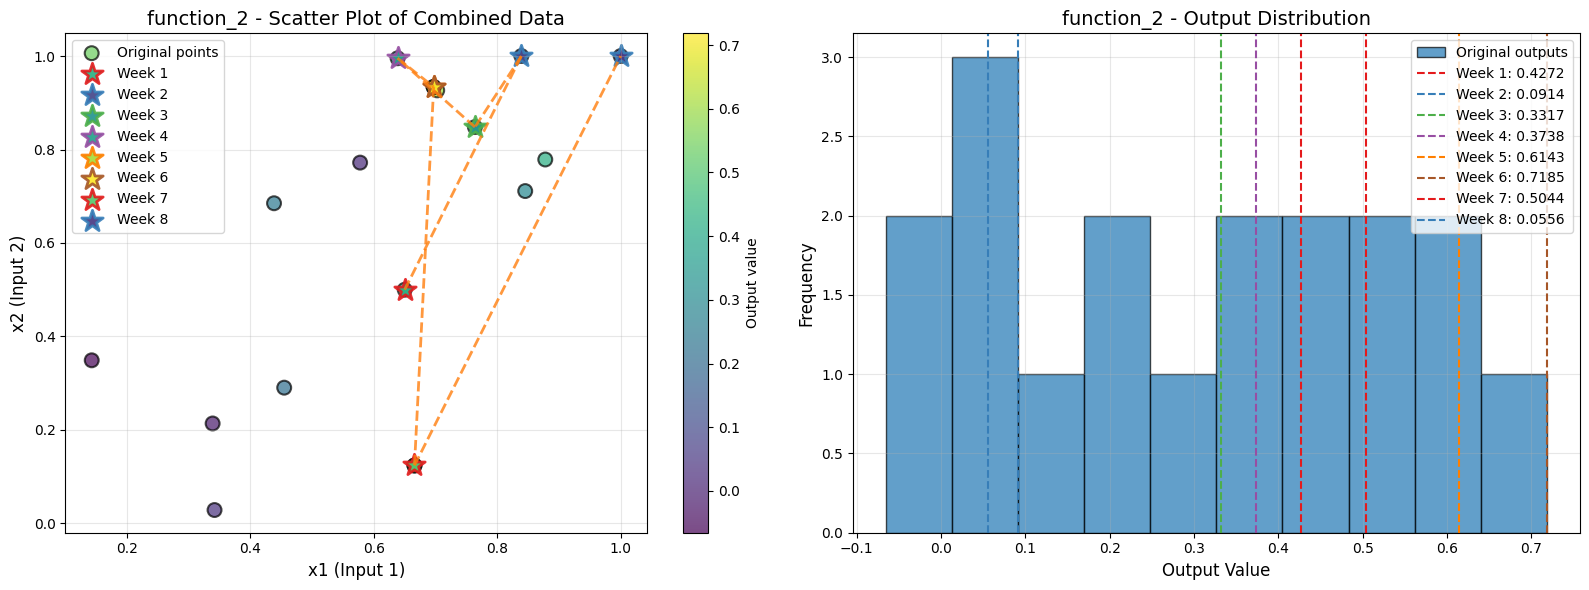

In [31]:
# Function 2 - Combine all data (initial + weeks 1-8)
function_name = 'function_2'

# Get original inputs and outputs
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']

# Get weekly new inputs and outputs
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']
week4_input = week4_data[function_name]['input']
week4_output = week4_data[function_name]['output']
week5_input = week5_data[function_name]['input']
week5_output = week5_data[function_name]['output']
week6_input = week6_data[function_name]['input']
week6_output = week6_data[function_name]['output']
week7_input = week7_data[function_name]['input']
week7_output = week7_data[function_name]['output']
week8_input = week8_data[function_name]['input']
week8_output = week8_data[function_name]['output']

# Combine all observed data
X_observed = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1),
    week4_input.reshape(1, -1),
    week5_input.reshape(1, -1),
    week6_input.reshape(1, -1),
    week7_input.reshape(1, -1),
    week8_input.reshape(1, -1)
])
y_observed = np.concatenate([
    original_outputs,
    np.array([week1_output]),
    np.array([week2_output]),
    np.array([week3_output]),
    np.array([week4_output]),
    np.array([week5_output]),
    np.array([week6_output]),
    np.array([week7_output]),
    np.array([week8_output])
])

# Validate progress
status, message, flag = validate_progress(y_observed, function_name)

print("=" * 60)
print(f"FUNCTION 2 - COMBINED DATA & VALIDATION")
print("=" * 60)
print(f"\nCombined inputs shape: {X_observed.shape}")
print(f"Combined outputs shape: {y_observed.shape}")
print(f"\nBest observed output so far: {y_observed.max():.6f}")
print(f"Mean output: {y_observed.mean():.6f}")
print(f"Std output: {y_observed.std():.6f}")
print(f"\n{'⚠️ ' if flag else '✓ '}PROGRESS STATUS: {status.upper()}")
print(f"  {message}")
print("=" * 60)

# Visualize: show all observed weekly points through week 8
plot_2d_scatter_with_distribution(
    X_observed, y_observed,
    week8_input, week8_output,
    function_name,
    weekly_points=[
        (week1_input, week1_output, "Week 1"),
        (week2_input, week2_output, "Week 2"),
        (week3_input, week3_output, "Week 3"),
        (week4_input, week4_output, "Week 4"),
        (week5_input, week5_output, "Week 5"),
        (week6_input, week6_output, "Week 6"),
        (week7_input, week7_output, "Week 7"),
        (week8_input, week8_output, "Week 8"),
    ],
    connect_points=True,
    connect_color="tab:orange"
)


In [32]:
# Function 2 - Local exploitative BO (week 9 update)
function_name = 'function_2'
n_dims = X_observed.shape[1]
bounds = [[0.0, 1.0]] * n_dims

# Week 9 changes:
# - merge duplicate and near-duplicate observations before GP fitting
# - fit a noise-aware GP so repeated evaluations do not create unrealistic spikes
# - search locally around the incumbent instead of globally over the whole box
bo = SimpleBayesianOptimization(
    bounds=bounds,
    n_initial=0,
    random_state=42,
    aggregate_tol=1e-3,
    trust_region_scale=0.075,
    local_topk=1,
)
bo.fit(X_observed, y_observed)

# Suggest next point by maximizing the GP mean locally near the incumbent
next_point = bo.suggest_next_point(beta=0.0)
pred_mean, pred_std = bo.predict(next_point.reshape(1, -1))
expected_value = float(pred_mean[0])
expected_std = float(pred_std[0])

best_idx = int(np.argmax(y_observed))
best_input = X_observed[best_idx]
distance_to_best = float(np.linalg.norm(next_point - best_input))
formatted_point = '-'.join([f'{x:.6f}' for x in next_point])

print('\n' + '=' * 60)
print('FUNCTION 2 - LOCAL EXPLOITATIVE BO (MEAN-ONLY)')
print('=' * 60)
print(f"Raw points used: {bo.fit_summary['raw_points']}")
print(f"Aggregated model points: {bo.fit_summary['model_points']}")
print(f"Merged clusters: {bo.fit_summary['merged_clusters']}")
print(f"Fitted kernel: {bo.fit_summary['kernel']}")
print(f'Suggested next point: {formatted_point}')
print(f'Predicted mean at next point (table "Output value"): {expected_value:.6f}')
print(f'Predicted std at next point: {expected_std:.6f}')
print(f'Distance to best observed input: {distance_to_best:.6f}')

y_min, y_max = float(np.min(y_observed)), float(np.max(y_observed))
margin = max(0.5, 0.5 * (y_max - y_min))
display_min, display_max = y_min - margin, y_max + margin
if expected_value < display_min or expected_value > display_max:
    print(
        f"WARNING: raw GP mean {expected_value:.4f} looks out of range [{display_min:.4f}, {display_max:.4f}]"
    )

if flag:
    print(f'\nWARNING: {message}')
    print('Consider checking whether the objective is still plateauing near the incumbent.')
print('=' * 60)

result_json = {
    'function_name': function_name,
    'next_point': next_point.tolist(),
    'formatted': formatted_point,
    'method': 'bayesian_optimization_exploitative_local_noise_aware',
    'acquisition': 'mean_local_trust_region',
    'expected_value': expected_value,
    'expected_std': expected_std,
    'distance_to_best_observed': distance_to_best,
    'raw_points': bo.fit_summary['raw_points'],
    'model_points': bo.fit_summary['model_points'],
    'merged_clusters': bo.fit_summary['merged_clusters'],
    'kernel': bo.fit_summary['kernel'],
    'validation_status': status,
    'validation_message': message,
    'validation_flag': flag
}

output_path = 'results/function2_next_point.json'
Path('results').mkdir(parents=True, exist_ok=True)
with open(output_path, 'w') as f:
    json.dump(result_json, f, indent=2)

print(f'\nResult saved to: {output_path}')



FUNCTION 2 - LOCAL EXPLOITATIVE BO (MEAN-ONLY)
Raw points used: 18
Aggregated model points: 16
Merged clusters: 2
Fitted kernel: 0.92**2 * RBF(length_scale=0.0645) + WhiteKernel(noise_level=0.024)
Suggested next point: 0.690682-0.939107
Predicted mean at next point (table "Output value"): 0.637943
Predicted std at next point: 0.048673
Distance to best observed input: 0.008397

Consider checking whether the objective is still plateauing near the incumbent.

Result saved to: results/function2_next_point.json


### Inputs/Outputs comparison table (Function 2)

Source, Input number, Output value, Distance to maximum input, Summary of progress. Proposed week 9 row uses the local mean-only BO suggestion and the **raw GP predicted mean** as the output value.

In [33]:
import scripts.utils.distance_utils as distance_utils
importlib.reload(distance_utils)
from scripts.utils.distance_utils import make_inputs_outputs_table

n_initial = original_inputs.shape[0]
table = make_inputs_outputs_table(
    X_observed, y_observed, n_initial,
    x_proposed=next_point,
    y_proposed=float(expected_value),
)

display(table)


,Source,Input number,Output value,Distance to maximum input,Summary of progress
0,initial,1,0.538996,0.810125,Initial
1,initial,2,0.420586,0.238108,Initial
2,initial,3,-0.065624,0.805481,Initial
3,initial,4,0.293993,0.267316,Initial
4,initial,5,0.214965,0.687170,Initial
5,initial,6,0.023106,0.200754,Initial
6,initial,7,0.244619,0.358747,Initial
7,initial,8,0.038749,0.972015,Initial
8,initial,9,-0.013858,0.803885,Initial
9,initial,10,0.611205,0.008979,Initial


### SUMMARY - FUNCTION 2 WITH LOCAL EXPLOITATIVE BO

In [34]:
print('=' * 60)
print('LOCAL EXPLOITATIVE BO (MEAN-ONLY) - SUMMARY')
print('Function 2')
print('=' * 60)
print('\nMethod: Gaussian Process, maximize mean locally with duplicate aggregation and noise modeling')
print('\nNext point for submission:\n')

json_path = 'results/function2_next_point.json'
if Path(json_path).exists():
    with open(json_path, 'r') as f:
        result = json.load(f)
        flag_symbol = 'WARNING: ' if result.get('validation_flag', False) else 'OK: '
        print(f"{flag_symbol}function_2: {result['formatted']}")
        print(f"  Predicted mean (table Output value): {result['expected_value']:.6f}")
        print(f"  Predicted std: {result.get('expected_std', float('nan')):.6f}")
        print(f"  Distance to best observed input: {result.get('distance_to_best_observed', float('nan')):.6f}")
        print(f"  Aggregated model points: {result.get('model_points', 'unknown')}")
        print(f"  Kernel: {result.get('kernel', 'unknown')}")
        print(f"  Status: {result.get('validation_status', 'unknown').upper()}")
        if result.get('validation_flag', False):
            print('\nWARNING: function_2 is still flagged for review')
            print('Check whether weekly outputs are still plateauing near the incumbent.')
else:
    print('function_2: [NOT GENERATED]')


LOCAL EXPLOITATIVE BO (MEAN-ONLY) - SUMMARY
Function 2

Method: Gaussian Process, maximize mean locally with duplicate aggregation and noise modeling

Next point for submission:

  Predicted mean (table Output value): 0.637943
  Predicted std: 0.048673
  Distance to best observed input: 0.008397
  Aggregated model points: 16
  Kernel: 0.92**2 * RBF(length_scale=0.0645) + WhiteKernel(noise_level=0.024)
  Status: PLATEAU

Check whether weekly outputs are still plateauing near the incumbent.
